  sim  1:  1500 records  (llm_calls_1.jsonl)
  sim  2:  1500 records  (llm_calls_1.jsonl)
  sim  3:  1500 records  (llm_calls_2.jsonl)
  sim  4:  1500 records  (llm_calls_3.jsonl)
  sim  5:  1500 records  (llm_calls_4.jsonl)
  sim  6:  1500 records  (llm_calls_1.jsonl)
  sim  7:  1500 records  (llm_calls_2.jsonl)
  sim  8:  1500 records  (llm_calls_1.jsonl)
  sim  9:  1500 records  (llm_calls_2.jsonl)
  sim 10:  1500 records  (llm_calls_3.jsonl)
Loaded 15000 records from 10 files.

Traces per phase:
   Incremental:  9323
         Cross:   182

Document frequency (% of traces containing the category):
     Strategy & Boundaries | incr  86.4% | cross  48.9%
              Optimization | incr  71.3% | cross  31.9%
                   Urgency | incr  23.1% | cross  94.0%
     Execution & Certainty | incr  25.0% | cross  97.3%
Saved figure -> cluster_shift_combined.png


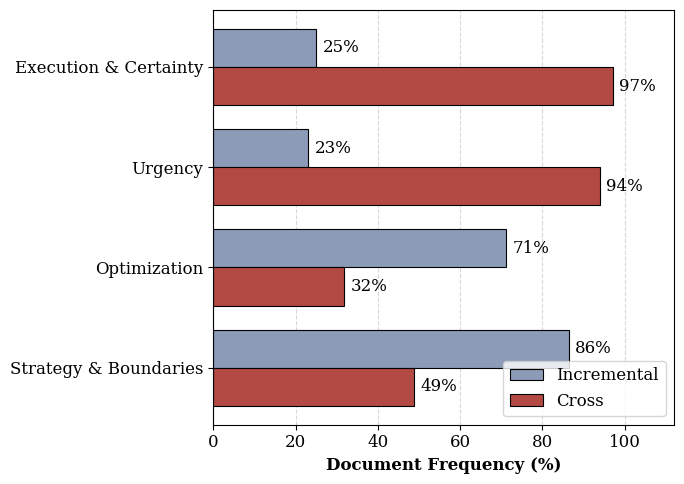

In [10]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

# You declare the files explicitly (see RUN cell), so leave this None. Set it to
# "gemini" if you ever pass mixed-model logs and want to keep only Gemini traces.
MODEL_FILTER = None
EPS = 1e-9

# Lexicon. Seed terms are the words italicised in the paper; the two broader
# categories ("& Boundaries", "& Certainty") also carry the extra senses their
# labels imply. Patterns catch morphological variants. Everything downstream is
# agnostic to these lists -- edit them to match your co-author's word lists.
# LEXICON = {
#     "Strategy & Boundaries": [
#     # planning / approach
#     r"\bplan\w*", r"\bapproach\w*", r"\bposition\w*",
#     # room / flexibility / room to manoeuvre
#     r"\bman[oe]+uvr\w*", r"\broom\b", r"\bflexib\w*", r"\bleeway\b", r"wiggle room",
#     # limits & boundaries  (do NOT add reservation -- it saturates both phases)
#     r"\blimit\w*", r"\bceiling\b", r"\bfloor\b", r"bottom line",
#     r"\bthreshold\w*", r"\bboundar\w*", r"\bconstraint\w*",
#     # patience / timing  (NOT bare "wait": collides with Urgency, fires on cross)
#     r"\bpatien\w*", r"\brush\w*", r"too soon", r"too early", r"still early",
#     # information control / probing
#     r"test the water\w*", r"\bgaug\w*", r"\breveal\w*", r"\bsignal\w*", r"\bconceal\w*",
#     # caution
#     r"\bconservativ\w*", r"\bcautio\w*", r"overpay\w*",
# ],
#     "Optimization": [
#         r"\bmaximi[sz]\w*", r"\bimprov\w*", r"\bincrement\w*", r"\baim\w*",
#     ],
#     "Urgency": [
#         r"\bimmediat\w*", r"\bfast\w*", r"no need to wait",
#     ],
#     "Execution & Certainty": [
#         r"\bsecur\w*", r"\bguarant\w*", r"\bmiss\w*", r"\brisk\w*",
#         r"\bcertain\w*", r"\bensur\w*", r"\bdefinit\w*", r"lock\w* in", r"\bcommit\w*",
#     ],
# }
# LEXICON = {
#     "Strategy & Boundaries": [        # room for manoeuvre, plan, limit
#         r"room for man[oe]+uvr\w*",
#         r"\bplan\w*",
#         r"\blimit\w*",
#     ],
#     "Optimization": [                 # maximize, improve, increment, aim
#         r"\bmaximi[sz]\w*",
#         r"\bimprov\w*",
#         r"\bincrement\w*",
#         r"\baim\w*",
#     ],
#     "Urgency": [                      # immediate, fast, no need to wait
#         r"\bimmediat\w*",
#         r"\bfast\w*",
#         r"no need to wait",
#     ],
#     "Execution & Certainty": [        # secure, guarantee, miss, risk
#         r"\bsecur\w*",
#         r"\bguarant\w*",
#         r"\bmiss\w*",
#         r"\brisk\w*",
#     ],
# }
LEXICON = {
    "Strategy & Boundaries": [
        r"\broom\b", r"room for man[oe]+uvr\w*", r"\bman[oe]+uvr\w*",
        r"\bstrateg\w*", r"\bplan\w*", r"\blimit\w*",
    ],
    "Optimization": [
        r"\bmaximi[sz]\w*", r"\bimprov\w*", r"\bcompetitiv\w*",
        r"\bincreas\w*", r"\bincrement\w*", r"\baim\w*",
    ],
    "Urgency": [
        r"\bimmediat\w*", r"\bfast\w*", r"\bhurr\w*",
        r"no need to wait", r"no need to overthink",
    ],
    "Execution & Certainty": [
        r"\bsecur\w*", r"\bguarant\w*", r"\bexecut\w*",
        r"\bmiss\w*", r"\brisk\w*",
    ],
}

# Order bottom -> top on the y-axis (Strategy at the bottom, Execution at top).
CATEGORIES = [
    "Strategy & Boundaries", "Optimization", "Urgency", "Execution & Certainty",
]
PHASES = ["increment", "cross"]
PHASE_LABELS = {"increment": "Incremental", "cross": "Cross"}
PHASE_COLORS = {"increment": "#8C9CB8", "cross": "#B24A43"}
BOLD_THRESHOLD = None  # bold value labels at/above this % (None to disable)

_COMPILED = {
    cat: [re.compile(p, flags=re.IGNORECASE) for p in pats]
    for cat, pats in LEXICON.items()
}

# --------------------------------------------------------------------------- #
# Parsing helpers
# --------------------------------------------------------------------------- #

_BID_RE = re.compile(r"Current standing bid:\s*(none|\$?[\d.]+)", re.IGNORECASE)
_ASK_RE = re.compile(r"Current standing ask:\s*(none|\$?[\d.]+)", re.IGNORECASE)
_PRICE_RE = re.compile(r'"price"\s*:\s*(null|-?[\d.]+)')


def iter_records(path):
    """Yield dict records from one file (JSON-lines, or a single JSON array)."""
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        return
    if text[0] == "[":
        try:
            for rec in json.loads(text):
                yield rec
            return
        except json.JSONDecodeError:
            pass
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            yield json.loads(line)
        except json.JSONDecodeError:
            continue


def load_records(sim_files):
    """Load every record from the explicit list of simulation files.

    Tags each record with `_source_file` and `_sim_index` (1-based, in the order
    given) so you can trace any row back to its file. Returns a flat list.
    """
    records = []
    for i, path in enumerate(sim_files, start=1):
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(f"Simulation file #{i} not found: {p}")
        n_before = len(records)
        for rec in iter_records(p):
            rec["_source_file"] = str(p)
            rec["_sim_index"] = i
            records.append(rec)
        print(f"  sim {i:>2}: {len(records) - n_before:>5} records  ({p.name})")
    print(f"Loaded {len(records)} records from {len(sim_files)} files.")
    return records


def _to_price(token):
    if token is None:
        return None
    token = str(token).strip().lower().lstrip("$")
    if token in ("none", "null", ""):
        return None
    try:
        return float(token)
    except ValueError:
        return None


def parse_standing(rec):
    text = rec.get("user_prompt") or rec.get("prompt") or ""
    bid = _BID_RE.search(text)
    ask = _ASK_RE.search(text)
    return (_to_price(bid.group(1)) if bid else None,
            _to_price(ask.group(1)) if ask else None)


def get_price(rec):
    resp = rec.get("response")
    if isinstance(resp, dict):
        return _to_price(resp.get("price"))
    if isinstance(resp, str):
        try:
            return _to_price(json.loads(resp).get("price"))
        except (json.JSONDecodeError, AttributeError):
            m = _PRICE_RE.search(resp)
            return _to_price(m.group(1)) if m else None
    return None


def classify_move(agent_type, price, bid, ask):
    """'cross', 'increment', or None (no effective order)."""
    if price is None:
        return None
    if agent_type == "buyer":
        if ask is not None and price >= ask - EPS:
            return "cross"
        if bid is None or price > bid + EPS:
            return "increment"
        return None
    if agent_type == "seller":
        if bid is not None and price <= bid + EPS:
            return "cross"
        if ask is None or price < ask - EPS:
            return "increment"
        return None
    return None


def present_categories(text):
    """Set of categories that appear at least once in the trace."""
    return {cat for cat, pats in _COMPILED.items()
            if any(pat.search(text) for pat in pats)}


def _keep(rec):
    if rec.get("strategy") not in (None, "llm"):
        return False
    if MODEL_FILTER and MODEL_FILTER not in str(rec.get("model_name", "")).lower():
        return False
    return True

# --------------------------------------------------------------------------- #
# Move table (handy for inspection in the notebook)
# --------------------------------------------------------------------------- #

def moves_dataframe(records):
    """One row per analysed move (classified + non-empty thinking), with a
    boolean column per category. This is exactly the population behind the
    figure, so you can sanity-check counts and read individual traces."""
    rows = []
    for rec in records:
        if not _keep(rec):
            continue
        bid, ask = parse_standing(rec)
        price = get_price(rec)
        phase = classify_move(rec.get("agent_type"), price, bid, ask)
        thinking = (rec.get("thinking") or "").strip()
        if phase is None or not thinking:
            continue
        cats = present_categories(thinking)
        rows.append({
            "sim": rec.get("_sim_index"),
            "round": rec.get("round"),
            "iteration": rec.get("iteration"),
            "agent_type": rec.get("agent_type"),
            "price": price, "bid": bid, "ask": ask,
            "phase": phase,
            **{c: (c in cats) for c in CATEGORIES},
            "thinking": thinking,
        })
    return pd.DataFrame(rows)

# --------------------------------------------------------------------------- #
# Aggregation
# --------------------------------------------------------------------------- #

def aggregate(records):
    """Per phase: how many traces contain each category, and total traces."""
    present = {ph: {c: 0 for c in CATEGORIES} for ph in PHASES}
    doc_totals = {ph: 0 for ph in PHASES}
    for rec in records:
        if not _keep(rec):
            continue
        phase = classify_move(rec.get("agent_type"), get_price(rec),
                              *parse_standing(rec))
        if phase is None:
            continue
        thinking = (rec.get("thinking") or "").strip()
        if not thinking:
            continue
        doc_totals[phase] += 1
        for cat in present_categories(thinking):
            present[phase][cat] += 1
    return present, doc_totals


def doc_frequencies(present, doc_totals):
    return {
        ph: {c: (100.0 * present[ph][c] / doc_totals[ph] if doc_totals[ph] else 0.0)
             for c in CATEGORIES}
        for ph in PHASES
    }

# --------------------------------------------------------------------------- #
# Plotting
# --------------------------------------------------------------------------- #

def plot_shift(freq, out_path=None, title="General Thematic Shift (All Agents)"):
    plt.rcParams.update({"font.family": "serif", "font.size": 12})
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    y = np.arange(len(CATEGORIES))
    height = 0.38
    for ph, off in [("increment", +height / 2), ("cross", -height / 2)]:
        vals = np.array([freq[ph][c] for c in CATEGORIES])
        ax.barh(y + off, vals, height, label=PHASE_LABELS[ph],
                color=PHASE_COLORS[ph], edgecolor="black", linewidth=0.8)
        for yi, v in zip(y + off, vals):
            weight = ("bold" if BOLD_THRESHOLD is not None and v >= BOLD_THRESHOLD
                      else "normal")
            ax.text(v + 1.5, yi, f"{v:.0f}%", va="center", ha="left",
                    fontsize=12, fontweight=weight)
    ax.set_yticks(y)
    ax.set_yticklabels(CATEGORIES)
    ax.set_xlabel("Document Frequency (%)", fontweight="bold")
    ax.set_xlim(0, 112)
    ax.set_xticks(range(0, 101, 20))
    # ax.set_title(title, fontweight="bold", pad=14)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", frameon=True, fontsize=12)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure -> {out_path}")
    return fig, ax


SIM_FILES = [
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260502_225103\logs\llm_calls_1.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260508_235659\logs\llm_calls_1.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260508_235659\logs\llm_calls_2.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260508_235659\logs\llm_calls_3.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260508_235659\logs\llm_calls_4.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260510_220004\logs\llm_calls_1.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260510_220004\logs\llm_calls_2.jsonl",    
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260511_082402\logs\llm_calls_1.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260511_082402\logs\llm_calls_2.jsonl",
    r"C:\Users\pauls\code\master-thesis\results\final\results_configs_final\smith1_gemini_large.yaml_20260511_082402\logs\llm_calls_3.jsonl",
]

records = load_records(SIM_FILES)
df = moves_dataframe(records)          # inspect: df, df["phase"].value_counts(), etc.

present, totals = aggregate(records)
freq = doc_frequencies(present, totals)

print("\nTraces per phase:")
for ph in PHASES:
    print(f"  {PHASE_LABELS[ph]:>12}: {totals[ph]:>5}")
print("\nDocument frequency (% of traces containing the category):")
for c in CATEGORIES:
    print(f"  {c:>24} | incr {freq['increment'][c]:5.1f}% | cross {freq['cross'][c]:5.1f}%")

fig, ax = plot_shift(freq, out_path="cluster_shift_combined.png")
plt.show()